## Carga de librería



In [12]:
import pandas as pd

## Carga csv

In [13]:
from google.colab import drive
drive.mount('/content/drive')
#df=pd.read_csv('/content/drive/MyDrive/Classroom/Colab Notebooks/SQL/Spotify/spotify_tracks.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Visualizacion general de los datos

In [14]:
df0=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SQL/Spotify/spotify_tracks.csv')
df=df0.copy()

In [15]:
df.head()

,id,name,genre,artists,album,popularity,duration_ms,explicit
0,7kr3xZk4yb3YSZ4VFtg2Qt,Acoustic,acoustic,Billy Raffoul,1975,58,172199,False
1,1kJygfS4eoVziBBI93MSYp,Acoustic,acoustic,Billy Raffoul,A Few More Hours at YYZ,57,172202,False
2,6lynns69p4zTCRxmmiSY1x,Here Comes the Sun - Acoustic,acoustic,"Molly Hocking, Bailey Rushlow",Here Comes the Sun (Acoustic),42,144786,False
3,1RC9slv335IfLce5vt9KTW,Acoustic #3,acoustic,The Goo Goo Dolls,Dizzy up the Girl,46,116573,False
4,5o9L8xBuILoVjLECSBi7Vo,My Love Mine All Mine - Acoustic Instrumental,acoustic,"Guus Dielissen, Casper Esmann",My Love Mine All Mine (Acoustic Instrumental),33,133922,False


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           6300 non-null   object
 1   name         6300 non-null   object
 2   genre        6300 non-null   object
 3   artists      6300 non-null   object
 4   album        6300 non-null   object
 5   popularity   6300 non-null   int64 
 6   duration_ms  6300 non-null   int64 
 7   explicit     6300 non-null   bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 350.8+ KB


In [17]:
df.isnull().sum()

,0
id,0
name,0
genre,0
artists,0
album,0
popularity,0
duration_ms,0
explicit,0


## Analisis de los datos

### Popularidad

<ipython-input-31-c73271024814>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_popular, x='popularity', y='track_artist', palette='viridis')


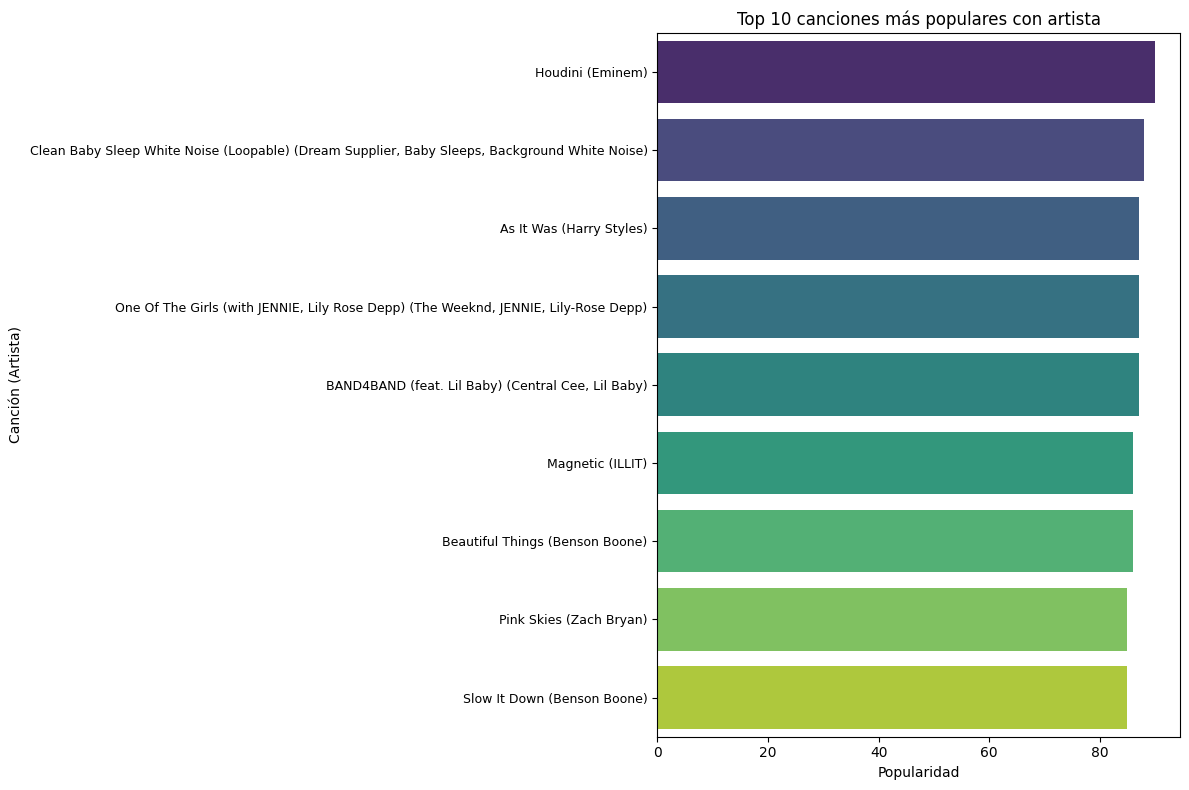

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
df['track_artist'] = df['name'] + ' (' + df['artists'] + ')'
df['track_artist_short'] = df['track_artist'].str.slice(0, 30) + '...'
top_popular = df.sort_values(by='popularity', ascending=False).head(10)

plt.figure(figsize=(12,8))
sns.barplot(data=top_popular, x='popularity', y='track_artist', palette='viridis')
plt.title('Top 10 canciones más populares con artista')
plt.xlabel('Popularidad')
plt.ylabel('Canción (Artista)')
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### Canciones con duracion más largas

<ipython-input-34-cb10c97ae05f>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_duracion,x='duracion', y='name', palette='magma')


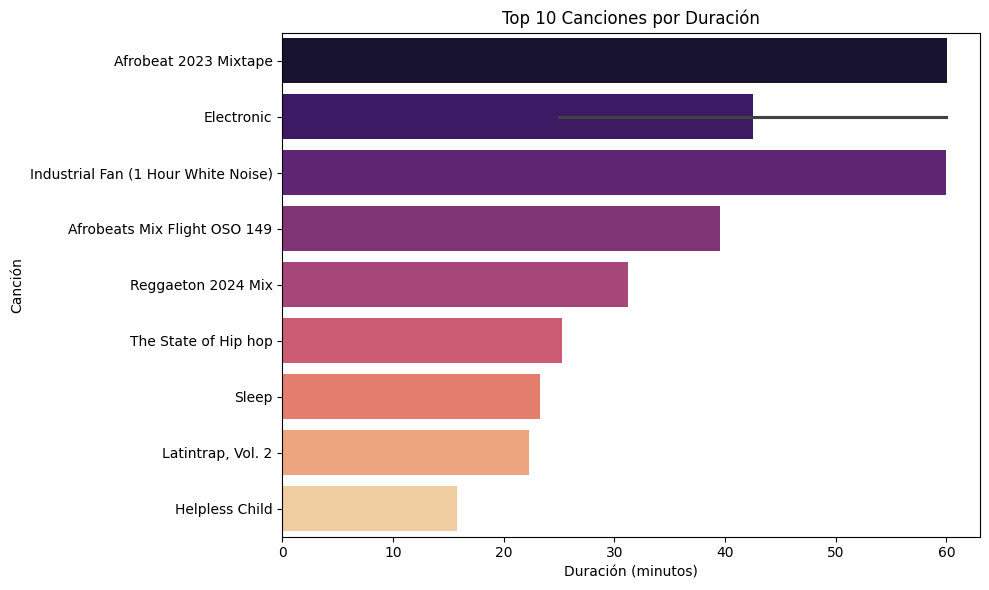

In [34]:
df['duracion'] = df['duration_ms'] / 60000
top_duracion = df.sort_values(by='duracion', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_duracion,x='duracion', y='name', palette='magma')
plt.title('Top 10 Canciones por Duración')
plt.xlabel('Duración (minutos)')
plt.ylabel('Canción')
plt.tight_layout()
plt.show()